<a href="https://colab.research.google.com/github/bnatsumi/calculo-numerico/blob/main/CN_atividade_pratica_5_NB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios: Sistemas lineares e implementação numérica
Cálculo Numérico, UNIFESP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# cores usadas nos gráficos
ROSA = "#F4A6B8"
VERMELHO = "#D9667F"
VERDE_CLARO = "#A8C69F"
VERDE = "#6B9362"
BEGE = "#FFF6E9"

plt.rcParams.update({
    "figure.facecolor": BEGE, "axes.facecolor": BEGE,
    "axes.edgecolor": VERDE, "axes.grid": True,
    "grid.color": "#EBDDC8", "font.size": 11,
})

## Parte 1: Conceitos e resolução manual

### Exercício 1: forma matricial $A\mathbf{x}=\mathbf{b}$

**a)**

$$
\underbrace{\begin{bmatrix} 2 & 1 \\ 1 & -3 \end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix} 7 \\ -5 \end{bmatrix}}_{\mathbf{b}}
$$

**b)**

$$
\underbrace{\begin{bmatrix} 1 & 2 & -1 \\ 3 & -1 & 2 \\ 2 & 1 & 1 \end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x \\ y \\ z \end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix} 2 \\ 9 \\ 7 \end{bmatrix}}_{\mathbf{b}}
$$

A matriz dos coeficientes $A$ tem os coeficientes de cada equação em cada linha, o vetor de incógnitas é $\mathbf{x}$ e o vetor independente é $\mathbf{b}$.

### Exercício 2: eliminação de Gauss

Sistema:
$$
\begin{cases} 2x + y - z = 8 \\ -3x - y + 2z = -11 \\ -2x + y + 2z = -3 \end{cases}
$$

Matriz aumentada inicial:

$$
\left[\begin{array}{ccc|c} 2 & 1 & -1 & 8 \\ -3 & -1 & 2 & -11 \\ -2 & 1 & 2 & -3 \end{array}\right]
$$

**Passo 1:** eliminar a primeira coluna abaixo do pivô $a_{11}=2$.
Multiplicadores: $m_{21} = -3/2$ e $m_{31} = -2/2 = -1$.
$L_2 \leftarrow L_2 + \tfrac{3}{2}L_1$ e $L_3 \leftarrow L_3 + L_1$:

$$
\left[\begin{array}{ccc|c} 2 & 1 & -1 & 8 \\ 0 & \tfrac12 & \tfrac12 & 1 \\ 0 & 2 & 1 & 5 \end{array}\right]
$$

**Passo 2:** eliminar a segunda coluna abaixo do pivô $a_{22}=\tfrac12$.
Multiplicador: $m_{32} = 2/(1/2) = 4$.
$L_3 \leftarrow L_3 - 4L_2$:

$$
\left[\begin{array}{ccc|c} 2 & 1 & -1 & 8 \\ 0 & \tfrac12 & \tfrac12 & 1 \\ 0 & 0 & -1 & 1 \end{array}\right]
$$

**Substituição regressiva:**

- $-z = 1 \Rightarrow z = -1$
- $\tfrac12 y + \tfrac12 z = 1 \Rightarrow \tfrac12 y = 1 + \tfrac12 = \tfrac32 \Rightarrow y = 3$
- $2x + y - z = 8 \Rightarrow 2x = 8 - 3 - 1 = 4 \Rightarrow x = 2$

$$\boxed{(x, y, z) = (2,\ 3,\ -1)}$$

Verificação na 2ª equação: $-3(2) - 3 + 2(-1) = -11$ (confere).

## Parte 2: Propriedades e interpretação

### Exercício 3: número de soluções

**a)** $\begin{cases} x + y = 3 \\ 2x + 2y = 6 \end{cases}$

$$
\left[\begin{array}{cc|c} 1 & 1 & 3 \\ 2 & 2 & 6 \end{array}\right]
\xrightarrow{L_2 \leftarrow L_2 - 2L_1}
\left[\begin{array}{cc|c} 1 & 1 & 3 \\ 0 & 0 & 0 \end{array}\right]
$$

A segunda linha zerou ($0=0$), então sobra uma equação para duas incógnitas: **infinitas soluções**, da forma $(x, y) = (t,\ 3-t)$. Posto de $A$ = posto de $[A|b]$ = 1 < 2 incógnitas.

**b)** $\begin{cases} x + y = 3 \\ 2x + 2y = 7 \end{cases}$

$$
\left[\begin{array}{cc|c} 1 & 1 & 3 \\ 2 & 2 & 7 \end{array}\right]
\xrightarrow{L_2 \leftarrow L_2 - 2L_1}
\left[\begin{array}{cc|c} 1 & 1 & 3 \\ 0 & 0 & 1 \end{array}\right]
$$

A segunda linha vira $0 = 1$, que é impossível: **nenhuma solução** (sistema incompatível). Posto de $A$ = 1 e posto de $[A|b]$ = 2.

**c)** $\begin{cases} x + y = 3 \\ 2x - y = 0 \end{cases}$

$$
\left[\begin{array}{cc|c} 1 & 1 & 3 \\ 2 & -1 & 0 \end{array}\right]
\xrightarrow{L_2 \leftarrow L_2 - 2L_1}
\left[\begin{array}{cc|c} 1 & 1 & 3 \\ 0 & -3 & -6 \end{array}\right]
$$

Dois pivôs não nulos: $-3y = -6 \Rightarrow y = 2$ e $x = 3 - 2 = 1$. **Solução única**: $(1, 2)$.

Geometricamente, cada equação é uma reta: no item a) as retas coincidem, no b) são paralelas distintas e no c) se cruzam em um ponto (gráfico abaixo).

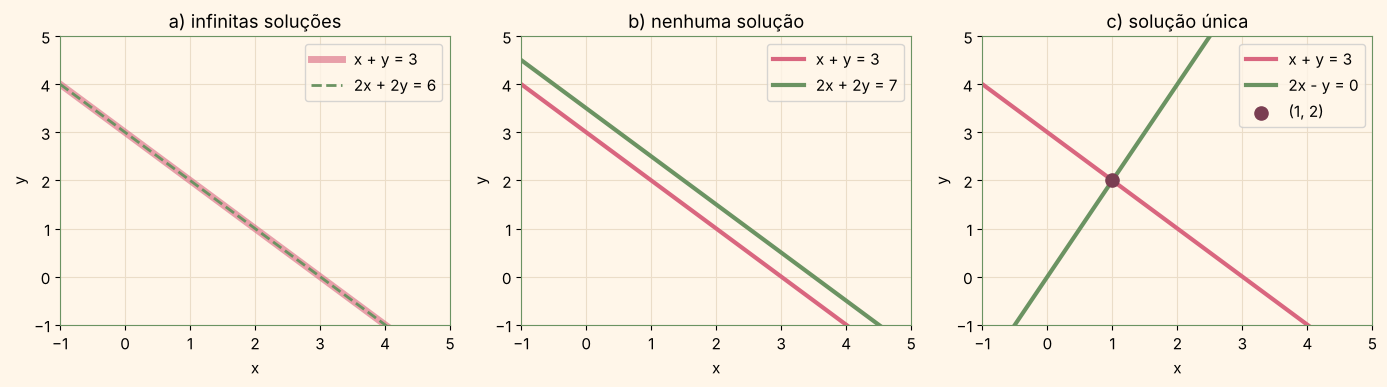

In [ ]:
# interpretação geométrica dos três sistemas do exercício 3
x = np.linspace(-1, 5, 100)
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

# a) retas coincidentes (a segunda é a primeira multiplicada por 2)
axs[0].plot(x, 3 - x, color=VERMELHO, lw=5, alpha=0.6, label="x + y = 3")
axs[0].plot(x, (6 - 2*x)/2, color=VERDE, lw=2, ls="--", label="2x + 2y = 6")
axs[0].set_title("a) infinitas soluções")

# b) retas paralelas
axs[1].plot(x, 3 - x, color=VERMELHO, lw=3, label="x + y = 3")
axs[1].plot(x, (7 - 2*x)/2, color=VERDE, lw=3, label="2x + 2y = 7")
axs[1].set_title("b) nenhuma solução")

# c) retas concorrentes
axs[2].plot(x, 3 - x, color=VERMELHO, lw=3, label="x + y = 3")
axs[2].plot(x, 2*x, color=VERDE, lw=3, label="2x - y = 0")
axs[2].scatter([1], [2], color="#7A3E52", s=90, zorder=5, label="(1, 2)")
axs[2].set_title("c) solução única")

for ax in axs:
    ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Parte 3: Implementação numérica em Python

### Exercício 4: eliminação de Gauss sem pivoteamento

In [ ]:
def gauss_sem_pivoteamento(A, b):
    # resolve Ax = b por eliminação de Gauss sem pivoteamento
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    # forma a matriz aumentada [A | b]
    Ab = np.hstack([A, b.reshape(-1, 1)])
    print("Matriz aumentada inicial:")
    print(Ab, "\n")

    # eliminação: zera os elementos abaixo de cada pivô
    for k in range(n - 1):
        if Ab[k, k] == 0:
            raise ZeroDivisionError(f"pivô nulo na posição ({k},{k}); seria preciso pivotear")
        for i in range(k + 1, n):
            m = Ab[i, k] / Ab[k, k]          # multiplicador
            Ab[i, k:] = Ab[i, k:] - m * Ab[k, k:]
        print(f"Após eliminar a coluna {k + 1}:")
        print(np.round(Ab, 4), "\n")

    if Ab[n - 1, n - 1] == 0:
        raise ZeroDivisionError("último pivô nulo; sistema sem solução única")

    # substituição regressiva
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, n] - Ab[i, i + 1:n] @ x[i + 1:]) / Ab[i, i]
    return x

# teste com o sistema do exercício 2
A2 = [[2, 1, -1], [-3, -1, 2], [-2, 1, 2]]
b2 = [8, -11, -3]

x_gauss = gauss_sem_pivoteamento(A2, b2)
x_numpy = np.linalg.solve(A2, b2)

print("Solução (Gauss):        ", x_gauss)
print("Solução (np.linalg.solve):", x_numpy)
print("Diferença máxima:        ", np.max(np.abs(x_gauss - x_numpy)))

Matriz aumentada inicial:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]] 

Após eliminar a coluna 1:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   2.   1.   5. ]] 

Após eliminar a coluna 2:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]] 

Solução (Gauss):         [ 2.  3. -1.]
Solução (np.linalg.solve): [ 2.  3. -1.]
Diferença máxima:         1.2212453270876722e-15


**Interpretação:** a solução obtida pelo algoritmo, $(2, 3, -1)$, é a mesma da resolução manual do exercício 2 e coincide com a do `numpy.linalg.solve` (diferença da ordem do erro de arredondamento ou nula). O `solve` usa fatoração LU com pivoteamento parcial, que é mais robusta; a versão sem pivoteamento funciona aqui porque nenhum pivô foi nulo, mas falharia (divisão por zero) ou perderia precisão em sistemas com pivôs nulos ou muito pequenos.

## Parte 4: Aplicação

### Exercício 5: modelo de balanço térmico

$$
\begin{bmatrix} 4 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 3 \end{bmatrix}
\begin{bmatrix} T_1 \\ T_2 \\ T_3 \end{bmatrix}
=
\begin{bmatrix} 15 \\ 10 \\ 10 \end{bmatrix}
$$

**a) Resolução manual**

Matriz aumentada:

$$
\left[\begin{array}{ccc|c} 4 & -1 & 0 & 15 \\ -1 & 4 & -1 & 10 \\ 0 & -1 & 3 & 10 \end{array}\right]
$$

**Passo 1:** pivô $a_{11}=4$, multiplicador $m_{21} = -1/4$ (e $m_{31}=0$, nada a fazer).
$L_2 \leftarrow L_2 + \tfrac14 L_1$:

$$
\left[\begin{array}{ccc|c} 4 & -1 & 0 & 15 \\ 0 & \tfrac{15}{4} & -1 & \tfrac{55}{4} \\ 0 & -1 & 3 & 10 \end{array}\right]
$$

**Passo 2:** pivô $a_{22}=\tfrac{15}{4}$, multiplicador $m_{32} = -1/(15/4) = -\tfrac{4}{15}$.
$L_3 \leftarrow L_3 + \tfrac{4}{15}L_2$:

$$
\left[\begin{array}{ccc|c} 4 & -1 & 0 & 15 \\ 0 & \tfrac{15}{4} & -1 & \tfrac{55}{4} \\ 0 & 0 & \tfrac{41}{15} & \tfrac{41}{3} \end{array}\right]
$$

(pois $3 - \tfrac{4}{15} = \tfrac{41}{15}$ e $10 + \tfrac{4}{15}\cdot\tfrac{55}{4} = 10 + \tfrac{11}{3} = \tfrac{41}{3}$).

**Substituição regressiva:**

- $\tfrac{41}{15}T_3 = \tfrac{41}{3} \Rightarrow T_3 = 5$
- $\tfrac{15}{4}T_2 - T_3 = \tfrac{55}{4} \Rightarrow \tfrac{15}{4}T_2 = \tfrac{75}{4} \Rightarrow T_2 = 5$
- $4T_1 - T_2 = 15 \Rightarrow 4T_1 = 20 \Rightarrow T_1 = 5$

$$\boxed{T_1 = T_2 = T_3 = 5}$$

**b) Implementação em Python** (reaproveitando a função do exercício 4)

In [ ]:
A5 = [[4, -1, 0], [-1, 4, -1], [0, -1, 3]]
b5 = [15, 10, 10]

T_gauss = gauss_sem_pivoteamento(A5, b5)
T_numpy = np.linalg.solve(A5, b5)

print("T (Gauss):", T_gauss)
print("T (numpy):", T_numpy)
print("Resíduo ||A T - b||:", np.linalg.norm(np.array(A5) @ T_gauss - b5))

Matriz aumentada inicial:
[[ 4. -1.  0. 15.]
 [-1.  4. -1. 10.]
 [ 0. -1.  3. 10.]] 

Após eliminar a coluna 1:
[[ 4.   -1.    0.   15.  ]
 [ 0.    3.75 -1.   13.75]
 [ 0.   -1.    3.   10.  ]] 

Após eliminar a coluna 2:
[[ 4.     -1.      0.     15.    ]
 [ 0.      3.75   -1.     13.75  ]
 [ 0.      0.      2.7333 13.6667]] 

T (Gauss): [5. 5. 5.]
T (numpy): [5. 5. 5.]
Resíduo ||A T - b||: 0.0


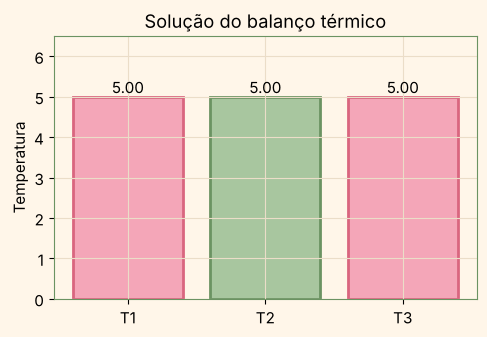

In [ ]:
# visualização das temperaturas encontradas
fig, ax = plt.subplots(figsize=(5, 3.5))
barras = ax.bar(["T1", "T2", "T3"], T_gauss, color=[ROSA, VERDE_CLARO, ROSA],
                edgecolor=[VERMELHO, VERDE, VERMELHO], lw=2)
ax.bar_label(barras, fmt="%.2f")
ax.set_ylabel("Temperatura")
ax.set_ylim(0, 6.5)
ax.set_title("Solução do balanço térmico")
plt.tight_layout()
plt.show()

**Interpretação:** as três temperaturas de equilíbrio resultam iguais a 5, o que confere com a resolução manual. O resultado é consistente com o modelo: a matriz é diagonalmente dominante (por linha, $|4| > 1$, $|4| > 2$, $|3| > 1$), então o sistema tem solução única e o método de Gauss sem pivoteamento é seguro, pois os pivôs ($4$, $15/4$, $41/15$) são todos não nulos.